In [1]:
import sys
import os
sys.path.append(os.pardir)

In [2]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

In [3]:
import matplotlib.pyplot as plt

In [4]:
#Modeling and Forecasting
import skforecast
import lightgbm
import sklearn
from lightgbm import LGBMRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import RFECV
from skforecast.recursive import ForecasterEquivalentDate, ForecasterRecursive
from skforecast.direct import ForecasterDirect
from skforecast.model_selection import TimeSeriesFold, bayesian_search_forecaster, backtesting_forecaster
from skforecast.feature_selection import select_features
from skforecast.preprocessing import RollingFeatures
from skforecast.plot import calculate_lag_autocorrelation, plot_residuals
from skforecast.metrics import calculate_coverage

/Users/maxwellgriffith/miniconda3/envs/loadcast/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import warnings
warnings.filterwarnings('once')

In [6]:
df = (pd.read_csv("../data/raw/gsloadtemp_clean.csv")
        .drop_duplicates()
        .pipe(lambda df: df.set_index(pd.to_datetime(df["date"])))
        .drop(columns = ["date"])
     )
#this will throw an error if there are duplicates
df.index = df.index.tz_localize(None)
df.index.freq = 'h'

In [7]:
df.shape

(26304, 2)

In [8]:
df.head()

,Demand,Temperature
date,,
2023-01-01 00:00:00,28771.933,6.90
2023-01-01 01:00:00,28488.282,7.70
2023-01-01 02:00:00,28073.965,6.55
2023-01-01 03:00:00,27756.863,5.80
2023-01-01 04:00:00,27271.343,5.65


In [9]:
### Train Val Test Split
TRAIN_START = "2023-01-01 00:00:00"
TRAIN_END   = "2024-06-30 23:00:00"
VAL_START   = "2024-07-01 00:00:00"
VAL_END     = "2024-12-31 23:00:00"
TEST_START  = "2025-01-01 00:00:00"
TEST_END    = "2025-12-31 23:00:00"

In [10]:
data = df.copy()
data_train = data.loc[: TRAIN_END, :].copy()
data_val   = data.loc[VAL_START:VAL_END, :].copy()
data_test  = data.loc[TEST_START:, :].copy()

print(f"Train dates      : {data_train.index.min()} --- {data_train.index.max()}  (n={len(data_train)})")
print(f"Validation dates : {data_val.index.min()} --- {data_val.index.max()}  (n={len(data_val)})")
print(f"Test dates       : {data_test.index.min()} --- {data_test.index.max()}  (n={len(data_test)})")

Train dates      : 2023-01-01 00:00:00 --- 2024-06-30 23:00:00  (n=13128)
Validation dates : 2024-07-01 00:00:00 --- 2024-12-31 23:00:00  (n=4416)
Test dates       : 2025-01-01 00:00:00 --- 2025-12-31 23:00:00  (n=8760)


### Baseline Forecaster
- seasonal naive forecaster used to compare performance of future models
- trained and evaluated with backtesting
- predicts each hour using the value of the same hour on the previous day

In [11]:
cv = TimeSeriesFold(
    steps              = 24,      # forecasting 24 hours ahead
    initial_train_size = len(data_train),  # full training set as starting point
    refit              = False,   # don't refit on each fold
    fixed_train_size   = False,   # growing window
)

In [12]:
# Create baseline: value of the same hour of the previous day
base_forecaster = ForecasterEquivalentDate(
                 offset    = pd.DateOffset(days=1),
                 n_offsets = 1
             )

# Train forecaster
#forecaster.fit(y=data.loc[:VAL_END, 'Demand'])

In [13]:
#Base line forecaster evaluation
metric, predictions = backtesting_forecaster(
                          forecaster = base_forecaster,
                          y          = data['Demand'],
                          cv         = cv,
                          metric     = 'mean_absolute_error'
                       )
metric

100%|███████████████████████████████████████████████████████████| 549/549 [00:02<00:00, 232.24it/s]


,mean_absolute_error
0,1428.35752


Error is on the high side let's look at the residuals to see any outliers

In [14]:
base_forecaster.fit(y=data.loc[:VAL_END]["Demand"], store_in_sample_residuals=True)
base_residuals = pd.Series(base_forecaster.in_sample_residuals_)

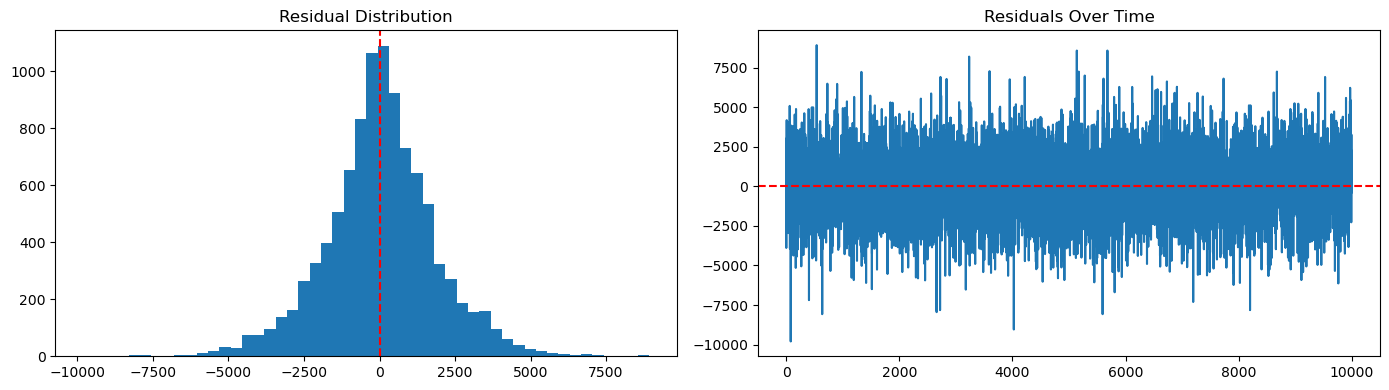

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution
axes[0].hist(base_residuals, bins=50)
axes[0].set_title("Residual Distribution")
axes[0].axvline(0, color="red", linestyle="--")

# Residuals over index (order they were generated)
axes[1].plot(base_residuals.values)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Residuals Over Time")

plt.tight_layout()
plt.show()

### Recursive Multi-step forecast
- use gradient descent for the estimator (the enginge that solves the Ax = y matrix)
- forecaster handles creating the matrix from the time series
- will use 24 lags to predict the outcome
- basic auto regressive model

In [16]:
# Create forecaster
ar_forecaster = ForecasterRecursive(
                 estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                 lags            = 24,
             )
#forecaster.fit(y=data.loc[:VAL_END, 'Demand'])

In [17]:
#Back test auto-regressive model
ar_metric, ar_predictions = backtesting_forecaster(
                          forecaster    = ar_forecaster,
                          y             = data['Demand'],
                          cv            = cv,
                          metric        = 'mean_absolute_error',
                          verbose       = False, # Set to False to avoid printing
                      )
ar_metric

100%|███████████████████████████████████████████████████████████| 549/549 [00:02<00:00, 262.14it/s]


,mean_absolute_error
0,1235.463647


That's a very high error, lets check the residuals to see if they are normally distributed and if there are any outliers

In [18]:
def plot_fit_res(forecaster, target = data):
    forecaster.fit(y=target.loc[:VAL_END]["Demand"], store_in_sample_residuals=True)
    residuals = pd.Series(forecaster.in_sample_residuals_)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Distribution
    axes[0].hist(residuals, bins=50)
    axes[0].set_title("Residual Distribution")
    axes[0].axvline(0, color="red", linestyle="--")
    
    # Residuals over index (order they were generated)
    axes[1].plot(residuals.values)
    axes[1].axhline(0, color="red", linestyle="--")
    axes[1].set_title("Residuals Over Time")
    
    plt.tight_layout()
    plt.show()

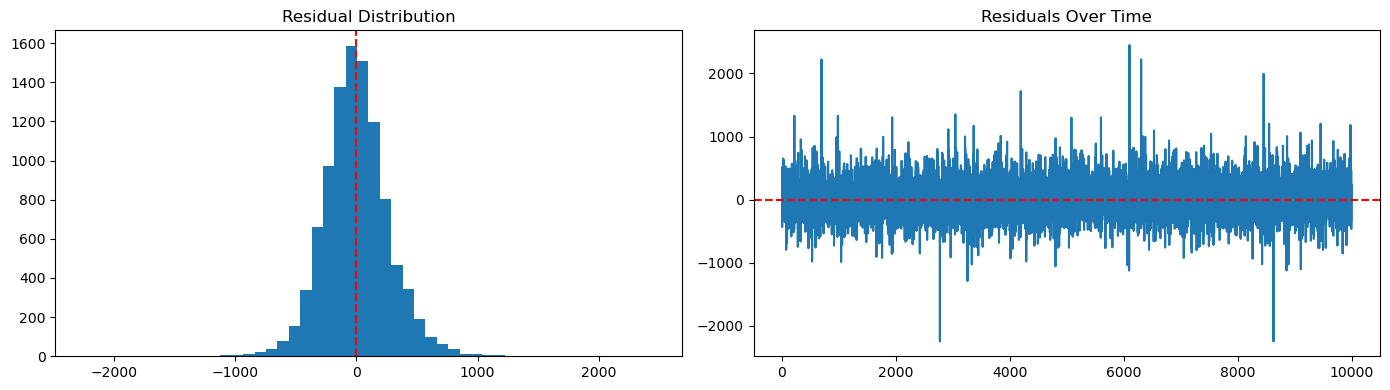

In [19]:
plot_fit_res(ar_forecaster)

the model is mostly normally distrubted, but there is clearly an issue with very high outliers in the residuals

#### let's look a the predicated values and the actuals

In [20]:
def plot_pred_real_res(predictions, actual = data):
    actual_fitted = predictions[["pred"]]
    actual_fitted = actual_fitted.join(actual[["Demand"]])
    actual_fitted["residual"]= actual_fitted["Demand"]-actual_fitted["pred"]

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    axes[0].plot(actual_fitted.index, actual_fitted["Demand"], label="Actual", color = "blue")
    axes[0].plot(actual_fitted.index, actual_fitted["pred"], label="Fitted", color = "orange")
    axes[0].legend()
   
    axes[1].plot(actual_fitted.index, actual_fitted["residual"], label="Residual", color = "red", alpha = 0.5)
    axes[1].set_ylim(-10000,10000)
    axes[1].legend()
    #axes.legend()
    plt.tight_layout()
    plt.show()

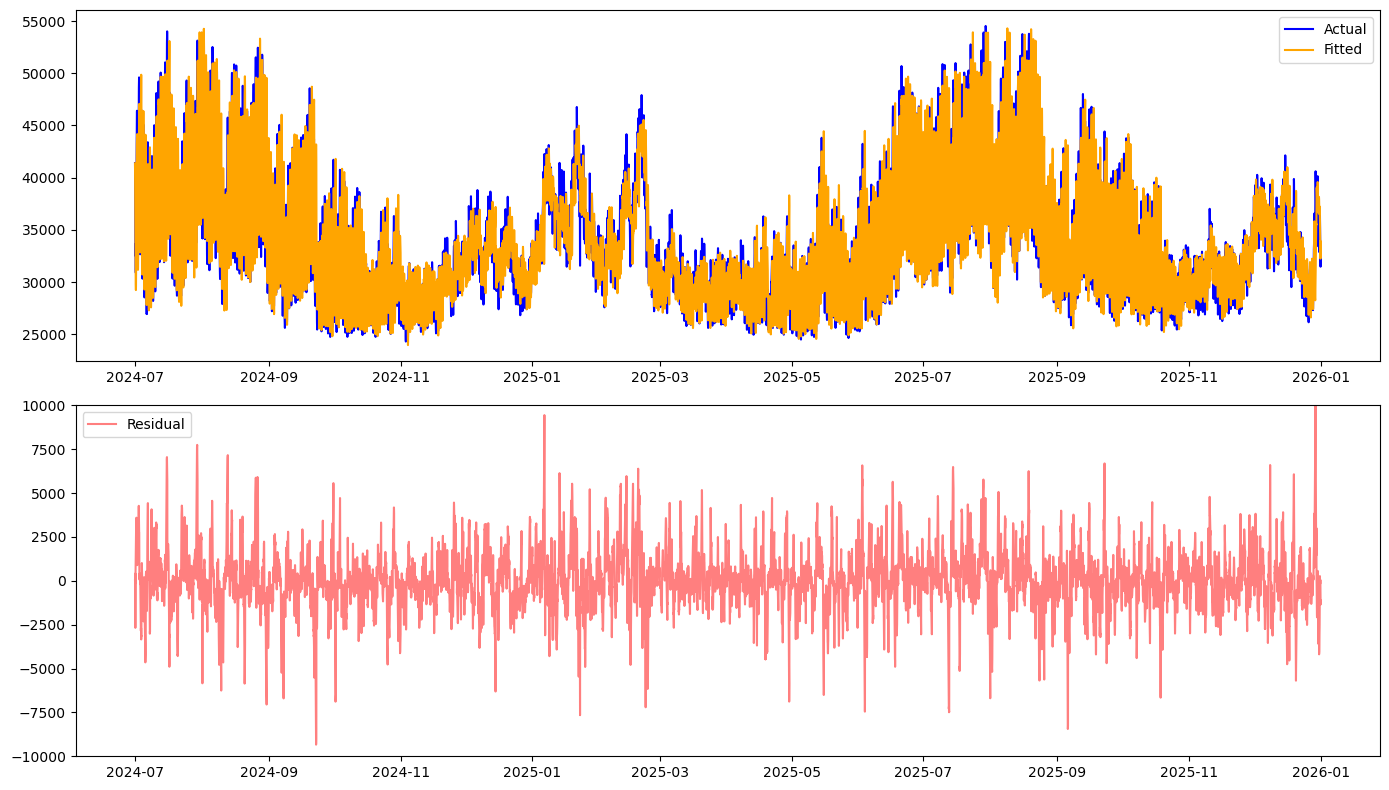

In [21]:
plot_pred_real_res(ar_predictions)

look at top outliers and their neighbors

In [22]:
"""
#create residual series with the acutal date index
residuals = pd.Series(
            forecaster.in_sample_residuals_,
            index = data.loc[:VAL_END].index[-len(forecaster.in_sample_residuals_):]
)
residuals.head()
"""

'\n#create residual series with the acutal date index\nresiduals = pd.Series(\n            forecaster.in_sample_residuals_,\n            index = data.loc[:VAL_END].index[-len(forecaster.in_sample_residuals_):]\n)\nresiduals.head()\n'

In [23]:
"""
outliers = residuals.abs().sort_values(ascending=False).head(10)
print(outliers)
"""

'\noutliers = residuals.abs().sort_values(ascending=False).head(10)\nprint(outliers)\n'

In [24]:
"""
fig, axes = plt.subplots(3, 1, figsize=(12, 9))

outlier_dates = ["2024-07-22 13:00:00", "2024-11-04 21:00:00", "2024-03-05 20:00:00"]

for ax, date in zip(axes, outlier_dates):
    date = pd.Timestamp(date)
    window = df.loc[date - pd.Timedelta(hours=): date + pd.Timedelta(hours=86), "Demand"]

    ax.plot(window.index, window.values, marker="o", color="steelblue")
    ax.axvline(date, color="red", linestyle="--", alpha=0.6, label="Outlier")
    ax.set_title(f"Demand around {date}")
    ax.set_ylabel("Demand")
    ax.legend()

plt.tight_layout()
plt.show()
"""

'\nfig, axes = plt.subplots(3, 1, figsize=(12, 9))\n\noutlier_dates = ["2024-07-22 13:00:00", "2024-11-04 21:00:00", "2024-03-05 20:00:00"]\n\nfor ax, date in zip(axes, outlier_dates):\n    date = pd.Timestamp(date)\n    window = df.loc[date - pd.Timedelta(hours=): date + pd.Timedelta(hours=86), "Demand"]\n\n    ax.plot(window.index, window.values, marker="o", color="steelblue")\n    ax.axvline(date, color="red", linestyle="--", alpha=0.6, label="Outlier")\n    ax.set_title(f"Demand around {date}")\n    ax.set_ylabel("Demand")\n    ax.legend()\n\nplt.tight_layout()\nplt.show()\n'

In [25]:
"""
#graphic the actual values, the predicts from AR and ARMA
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(df.loc["2024-03"].index, df.loc["2024-03"]["Demand"], label="2024 Demand", color="blue", alpha=0.5)
ax.plot(df.loc["2024-03"].index, df.loc["2023-03"]["Demand"], label="2023 Demand", color="orange", alpha=0.5)

#ax.set_title("SPP Load — Demand with 3-Day Moving Average")
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.legend()

plt.tight_layout()
plt.show()
"""

'\n#graphic the actual values, the predicts from AR and ARMA\nfig, ax = plt.subplots(figsize=(15, 5))\n\nax.plot(df.loc["2024-03"].index, df.loc["2024-03"]["Demand"], label="2024 Demand", color="blue", alpha=0.5)\nax.plot(df.loc["2024-03"].index, df.loc["2023-03"]["Demand"], label="2023 Demand", color="orange", alpha=0.5)\n\n#ax.set_title("SPP Load — Demand with 3-Day Moving Average")\nax.set_xlabel("Date")\nax.set_ylabel("Load (MW)")\nax.legend()\n\nplt.tight_layout()\nplt.show()\n'

In [26]:
#well that's a problem

### Retrain while remove flat runs of data (EIA data only)

In [27]:
"""
DROP_END = "2025-05-18 23:00:00"
data_NAN = data.loc[: DROP_END, :].copy()
data_NAN.tail()
"""

'\nDROP_END = "2025-05-18 23:00:00"\ndata_NAN = data.loc[: DROP_END, :].copy()\ndata_NAN.tail()\n'

In [28]:
"""
#find weeks that have repeated values within the week but might not be completely bad
#find partial flat runs where there is a long stretch without a difference in demand value
# Flag any hour where demand barely changed from the previous hour
data_NAN["diff"] = data_NAN["Demand"].diff().abs()

# Find runs of near-zero change (adjust threshold based on your typical hour-to-hour variation)
flat_threshold = 5  # MW — tune this based on your data's normal volatility
data_NAN["is_flat"] = data_NAN["diff"] < flat_threshold

# Find consecutive flat runs of meaningful length
data_NAN["flat_group"] = (data_NAN["is_flat"] != data_NAN["is_flat"].shift()).cumsum()
flat_runs = (data_NAN[data_NAN["is_flat"]]
    .groupby("flat_group")
    .agg(start=("Demand", lambda x: x.index[0]),
         end=("Demand", lambda x: x.index[-1]),
         length=("Demand", "size"))
)
"""

'\n#find weeks that have repeated values within the week but might not be completely bad\n#find partial flat runs where there is a long stretch without a difference in demand value\n# Flag any hour where demand barely changed from the previous hour\ndata_NAN["diff"] = data_NAN["Demand"].diff().abs()\n\n# Find runs of near-zero change (adjust threshold based on your typical hour-to-hour variation)\nflat_threshold = 5  # MW — tune this based on your data\'s normal volatility\ndata_NAN["is_flat"] = data_NAN["diff"] < flat_threshold\n\n# Find consecutive flat runs of meaningful length\ndata_NAN["flat_group"] = (data_NAN["is_flat"] != data_NAN["is_flat"].shift()).cumsum()\nflat_runs = (data_NAN[data_NAN["is_flat"]]\n    .groupby("flat_group")\n    .agg(start=("Demand", lambda x: x.index[0]),\n         end=("Demand", lambda x: x.index[-1]),\n         length=("Demand", "size"))\n)\n'

In [29]:
"""
# Only keep runs of meaningful length (e.g. 3+ consecutive flat hours)
suspicious_runs = flat_runs[flat_runs["length"] >= 5].sort_values("start", ascending=True)
suspicious_runs
"""

'\n# Only keep runs of meaningful length (e.g. 3+ consecutive flat hours)\nsuspicious_runs = flat_runs[flat_runs["length"] >= 5].sort_values("start", ascending=True)\nsuspicious_runs\n'

In [30]:
"""
def flag_suspicious_runs_as_nan(df, suspicious_runs, column="Demand"):
    df = df.copy()
    for _, row in suspicious_runs.iterrows():
        df.loc[row["start"]:row["end"], column] = np.nan
    return df
"""

'\ndef flag_suspicious_runs_as_nan(df, suspicious_runs, column="Demand"):\n    df = df.copy()\n    for _, row in suspicious_runs.iterrows():\n        df.loc[row["start"]:row["end"], column] = np.nan\n    return df\n'

In [31]:
#data_NAN = flag_suspicious_runs_as_nan(data_NAN, suspicious_runs)

In [32]:
"""
# Create forecaster
NAN_forecaster = ForecasterRecursive(
                 estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                 lags            = 24,
                 dropna_from_series = False,
             )
NAN_forecaster.fit(y=data_NAN['Demand'], suppress_warnings=True, store_in_sample_residuals=True)
"""

"\n# Create forecaster\nNAN_forecaster = ForecasterRecursive(\n                 estimator       = LGBMRegressor(random_state=15926, verbose=-1),\n                 lags            = 24,\n                 dropna_from_series = False,\n             )\nNAN_forecaster.fit(y=data_NAN['Demand'], suppress_warnings=True, store_in_sample_residuals=True)\n"

In [33]:
#residuals = pd.Series(NAN_forecaster.in_sample_residuals_)

In [34]:
"""
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution
axes[0].hist(residuals, bins=50)
axes[0].set_title("Residual Distribution")
axes[0].axvline(0, color="red", linestyle="--")

# Residuals over index (order they were generated)
axes[1].plot(residuals.values)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Residuals Over Time")

plt.tight_layout()
plt.show()
"""

'\nfig, axes = plt.subplots(1, 2, figsize=(14, 4))\n\n# Distribution\naxes[0].hist(residuals, bins=50)\naxes[0].set_title("Residual Distribution")\naxes[0].axvline(0, color="red", linestyle="--")\n\n# Residuals over index (order they were generated)\naxes[1].plot(residuals.values)\naxes[1].axhline(0, color="red", linestyle="--")\naxes[1].set_title("Residuals Over Time")\n\nplt.tight_layout()\nplt.show()\n'

In [35]:
"""
cv = TimeSeriesFold(
         steps              = 7,
         initial_train_size = len(data_train),
         refit              = False,
         fixed_train_size   = False,
     )
 """

'\ncv = TimeSeriesFold(\n         steps              = 7,\n         initial_train_size = len(data_train),\n         refit              = False,\n         fixed_train_size   = False,\n     )\n '

In [36]:
"""
# you can't back test over a range that has NaNs on the target variable because this will create an error
# can't calculate MSE on a NaN value
arNAN_metric, arNAN_predictions = backtesting_forecaster(
                          forecaster    = NAN_forecaster,
                          y             = data_NAN['Demand'],
                          cv            = cv,
                          metric        = 'mean_absolute_error',
                          verbose       = False, # Set to False to avoid printing
                          show_progress     = True,
                        suppress_warnings = True
                    )
"""

"\n# you can't back test over a range that has NaNs on the target variable because this will create an error\n# can't calculate MSE on a NaN value\narNAN_metric, arNAN_predictions = backtesting_forecaster(\n                          forecaster    = NAN_forecaster,\n                          y             = data_NAN['Demand'],\n                          cv            = cv,\n                          metric        = 'mean_absolute_error',\n                          verbose       = False, # Set to False to avoid printing\n                          show_progress     = True,\n                        suppress_warnings = True\n                    )\n"

### --------

In [37]:
"""
# Add a three day moving average: Auto Regressive Moving Average model
#Create forecaster
window_features = RollingFeatures(stats=["mean"], window_sizes=24 * 3)
forecaster = ForecasterRecursive(
                 estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                 lags            = 24,
                 window_features = window_features
             )
 """

'\n# Add a three day moving average: Auto Regressive Moving Average model\n#Create forecaster\nwindow_features = RollingFeatures(stats=["mean"], window_sizes=24 * 3)\nforecaster = ForecasterRecursive(\n                 estimator       = LGBMRegressor(random_state=15926, verbose=-1),\n                 lags            = 24,\n                 window_features = window_features\n             )\n '

In [38]:
"""
#Back test auto-regressive moving average model
arma_metric, arma_predictions = backtesting_forecaster(
                          forecaster    = forecaster,
                          y             = data['Demand'],
                          cv            = cv,
                          metric        = 'mean_absolute_error',
                          verbose       = False, # Set to False to avoid printing
                      )
arma_metric
"""

"\n#Back test auto-regressive moving average model\narma_metric, arma_predictions = backtesting_forecaster(\n                          forecaster    = forecaster,\n                          y             = data['Demand'],\n                          cv            = cv,\n                          metric        = 'mean_absolute_error',\n                          verbose       = False, # Set to False to avoid printing\n                      )\narma_metric\n"

In [39]:
"""
#graphic the actual values, the predicts from AR and ARMA
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(data_test.loc["2025-01"].index, data_test.loc["2025-01"]["Demand"], label="Demand", color="blue", alpha=0.5)
ax.plot(ar_predictions.loc["2025-01"].index, ar_predictions.loc["2025-01"]["pred"], label="AR Predictions", color="red", linewidth=2)
ax.plot(arma_predictions.loc["2025-01"].index, arma_predictions.loc["2025-01"]["pred"], label="ARMA Predictions", color="orange", linewidth=2)

ax.set_title("SPP Load — Demand with 3-Day Moving Average")
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.legend()

plt.tight_layout()
plt.show()
"""

'\n#graphic the actual values, the predicts from AR and ARMA\nfig, ax = plt.subplots(figsize=(15, 5))\n\nax.plot(data_test.loc["2025-01"].index, data_test.loc["2025-01"]["Demand"], label="Demand", color="blue", alpha=0.5)\nax.plot(ar_predictions.loc["2025-01"].index, ar_predictions.loc["2025-01"]["pred"], label="AR Predictions", color="red", linewidth=2)\nax.plot(arma_predictions.loc["2025-01"].index, arma_predictions.loc["2025-01"]["pred"], label="ARMA Predictions", color="orange", linewidth=2)\n\nax.set_title("SPP Load — Demand with 3-Day Moving Average")\nax.set_xlabel("Date")\nax.set_ylabel("Load (MW)")\nax.legend()\n\nplt.tight_layout()\nplt.show()\n'

issue with big divergence with large increases/decreases in load. the prediction and actual are almost opposites of each other. This is a major flaw as large swings in load would be of greater importance when planning based on a forecast

### Exogenous Variables
- values of the exogenous variables must be known at the time of prediction.
- we will use temperature, daylight time, and calendar features

In [40]:
ar_metric

,mean_absolute_error
0,1235.463647


In [41]:
# let's add temperature as an exogenous variable
#Back test auto-regressive model
ar_temp_metric, ar_temp_predictions = backtesting_forecaster(
                          forecaster    = ar_forecaster,
                          y             = data['Demand'],
                          exog          = data['Temperature'],
                          cv            = cv,
                          metric        = 'mean_absolute_error',
                          verbose       = False, # Set to False to avoid printing
                      )
ar_temp_metric

100%|███████████████████████████████████████████████████████████| 549/549 [00:02<00:00, 221.53it/s]


,mean_absolute_error
0,1113.868769


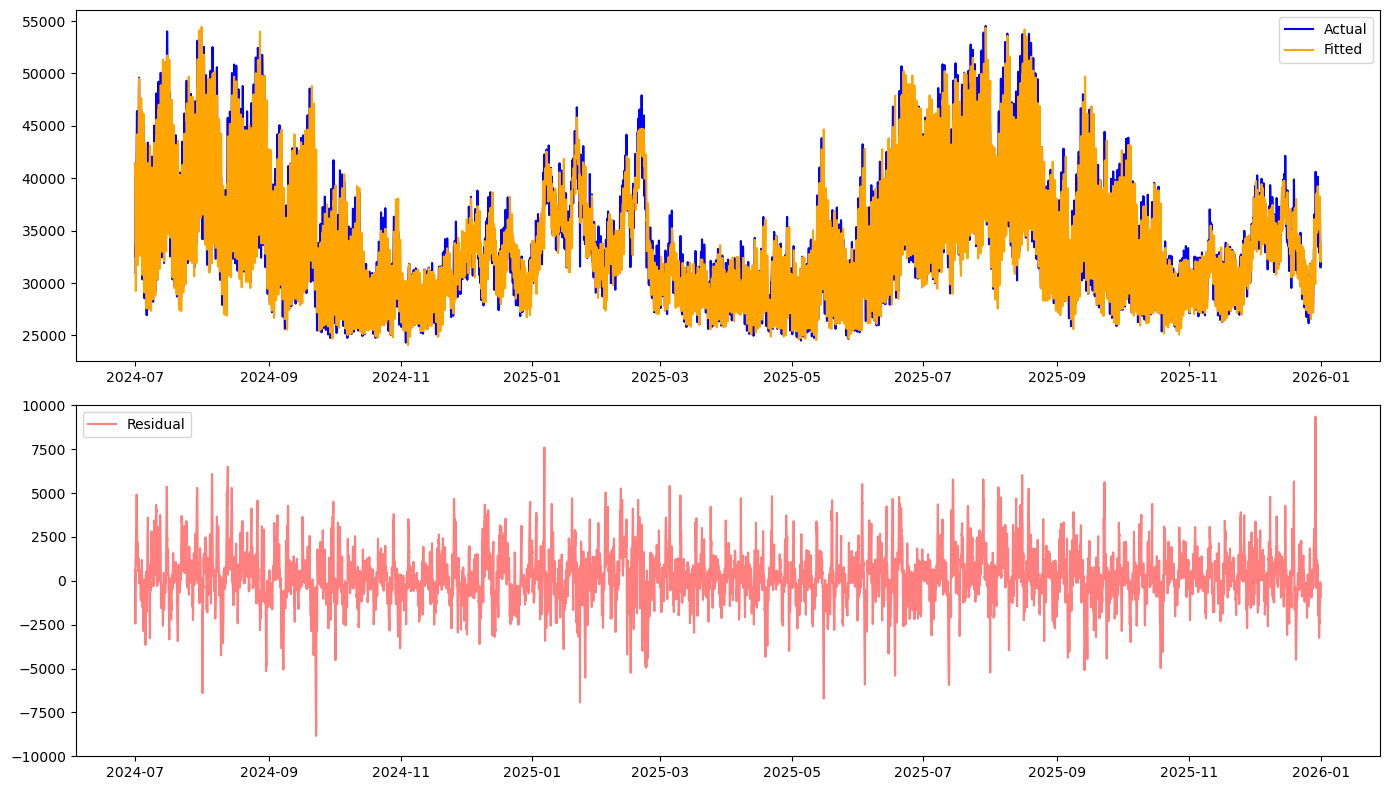

In [42]:
plot_pred_real_res(ar_temp_predictions)

there are still some large outliers in the residuals but they overall look more homoscedastic

In [43]:
from features import set_holidays, cal_features, cyclic_features

In [44]:
data = df.copy()
data = (data
            .pipe(set_holidays)
            .pipe(cal_features)
            .pipe(cyclic_features)
            .assign(Holiday=lambda d: d["Holiday"].astype(int))
            .assign(Temp_3D_Mean=lambda d: d["Temperature"].rolling("3D", center = False).mean())
            .assign(Temp_2D_Mean =lambda d: d["Temperature"].rolling("2D", center = False).mean())
            .assign(Temp_2D_Max =lambda d: d["Temperature"].rolling("2D", center = False).max())
            .assign(Temp_2D_Min =lambda d: d["Temperature"].rolling("2D", center = False).min())
            .assign(Temp_1D_Max =lambda d: d["Temperature"].rolling("1D", center = False).max())
            .assign(Temp_1D_Min =lambda d: d["Temperature"].rolling("1D", center = False).min())
           )

In [45]:
data.head()

,Demand,Temperature,Holiday,month,week,day_of_week,hour,month_sin,month_cos,week_sin,...,day_sin,day_cos,hour_sin,hour_cos,Temp_3D_Mean,Temp_2D_Mean,Temp_2D_Max,Temp_2D_Min,Temp_1D_Max,Temp_1D_Min
date,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,28771.933,6.90,0,1,52,6,0,0.5,0.866025,0.0,...,-0.781831,0.62349,0.000000,1.000000,6.9000,6.9000,6.9,6.90,6.9,6.90
2023-01-01 01:00:00,28488.282,7.70,0,1,52,6,1,0.5,0.866025,0.0,...,-0.781831,0.62349,0.258819,0.965926,7.3000,7.3000,7.7,6.90,7.7,6.90
2023-01-01 02:00:00,28073.965,6.55,0,1,52,6,2,0.5,0.866025,0.0,...,-0.781831,0.62349,0.500000,0.866025,7.0500,7.0500,7.7,6.55,7.7,6.55
2023-01-01 03:00:00,27756.863,5.80,0,1,52,6,3,0.5,0.866025,0.0,...,-0.781831,0.62349,0.707107,0.707107,6.7375,6.7375,7.7,5.80,7.7,5.80
2023-01-01 04:00:00,27271.343,5.65,0,1,52,6,4,0.5,0.866025,0.0,...,-0.781831,0.62349,0.866025,0.500000,6.5200,6.5200,7.7,5.65,7.7,5.65


In [46]:
exo_vars = [col for col in data.columns if col != "Demand"]
exo_vars

['Temperature',
 'Holiday',
 'month',
 'week',
 'day_of_week',
 'hour',
 'month_sin',
 'month_cos',
 'week_sin',
 'week_cos',
 'day_sin',
 'day_cos',
 'hour_sin',
 'hour_cos',
 'Temp_3D_Mean',
 'Temp_2D_Mean',
 'Temp_2D_Max',
 'Temp_2D_Min',
 'Temp_1D_Max',
 'Temp_1D_Min']

In [47]:
#resplit the data
data_train = data.loc[: TRAIN_END, :].copy()
data_val   = data.loc[VAL_START:VAL_END, :].copy()
data_test  = data.loc[TEST_START:, :].copy()

print(f"Train dates      : {data_train.index.min()} --- {data_train.index.max()}  (n={len(data_train)})")
print(f"Validation dates : {data_val.index.min()} --- {data_val.index.max()}  (n={len(data_val)})")
print(f"Test dates       : {data_test.index.min()} --- {data_test.index.max()}  (n={len(data_test)})")

Train dates      : 2023-01-01 00:00:00 --- 2024-06-30 23:00:00  (n=13128)
Validation dates : 2024-07-01 00:00:00 --- 2024-12-31 23:00:00  (n=4416)
Test dates       : 2025-01-01 00:00:00 --- 2025-12-31 23:00:00  (n=8760)


In [48]:
"""
#use this if you want to use window functions
# Add a three day moving average: Auto Regressive Moving Average model
#Create forecaster
window_features = RollingFeatures(stats=["mean"], window_sizes=24 * 3)
arma_forecaster = ForecasterRecursive(
                 estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                 lags            = 24,
                 window_features = window_features
             )
"""

'\n#use this if you want to use window functions\n# Add a three day moving average: Auto Regressive Moving Average model\n#Create forecaster\nwindow_features = RollingFeatures(stats=["mean"], window_sizes=24 * 3)\narma_forecaster = ForecasterRecursive(\n                 estimator       = LGBMRegressor(random_state=15926, verbose=-1),\n                 lags            = 24,\n                 window_features = window_features\n             )\n'

In [49]:
# back test the model again with exogenous variables
ar_exo_metric, ar_exo_predictions = backtesting_forecaster(
                          forecaster = ar_forecaster,
                          y          = data['Demand'],
                          exog       = data[exo_vars],
                          cv         = cv,
                          metric     = 'mean_absolute_error'
                      )
ar_exo_metric

100%|███████████████████████████████████████████████████████████| 549/549 [00:03<00:00, 163.63it/s]


,mean_absolute_error
0,903.540388


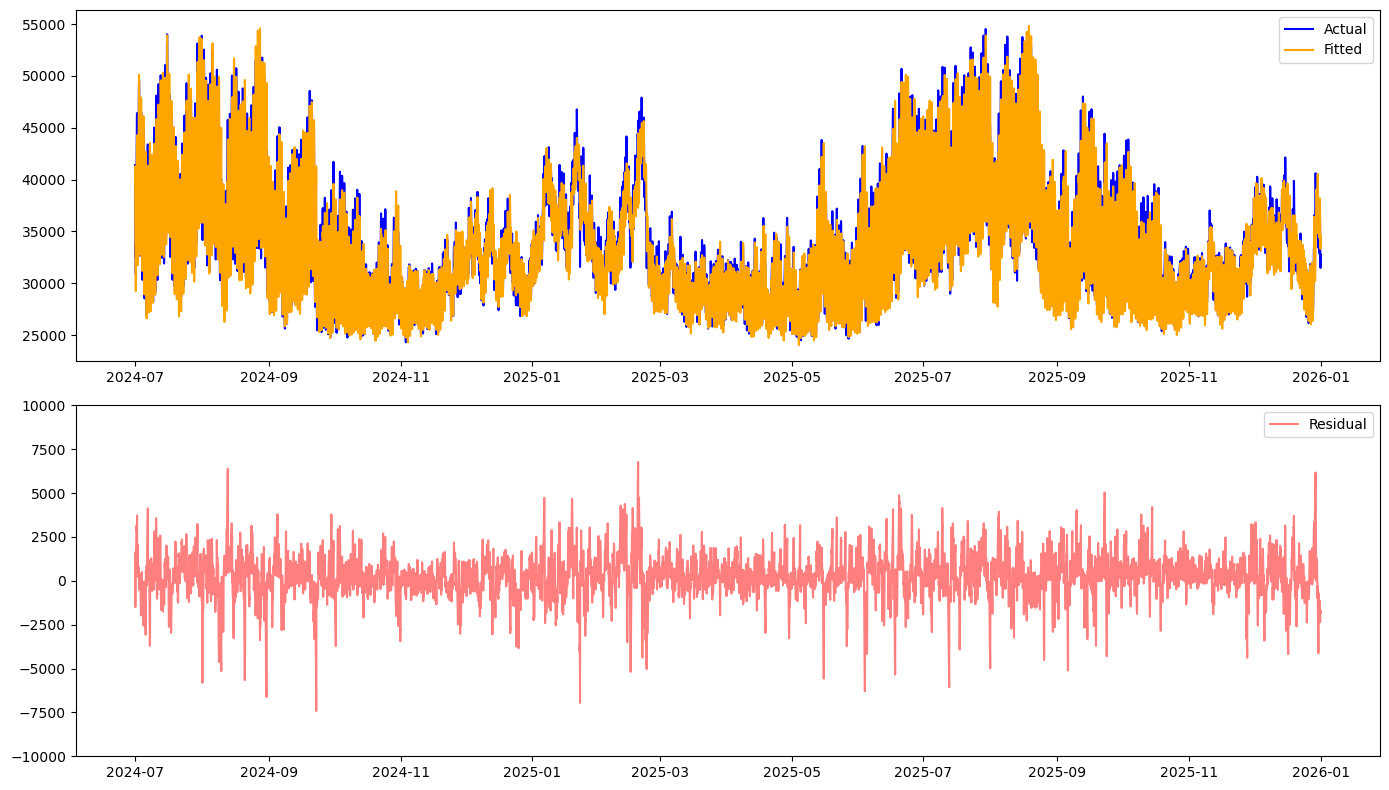

In [50]:
plot_pred_real_res(ar_exo_predictions)

In [51]:
"""
#Plot actuals and predications for jan 2025
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(data_test.loc["2025-01"].index, data_test.loc["2025-01"]["Demand"], label="Demand", color="blue", alpha=0.5)
#ax.plot(predictions.loc["2025-01"].index, predictions.loc["2025-01"]["pred"], label="ARMA Predictions", color="red", linewidth=2)
ax.plot(predictions.loc["2025-01"].index, predictions.loc["2025-01"]["pred"], label="ARMA Predictions", color="orange", linewidth=2)

ax.set_title("SPP Load — Demand with 3-Day Moving Average")
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.legend()

plt.tight_layout()
plt.show()
"""

'\n#Plot actuals and predications for jan 2025\nfig, ax = plt.subplots(figsize=(15, 5))\n\nax.plot(data_test.loc["2025-01"].index, data_test.loc["2025-01"]["Demand"], label="Demand", color="blue", alpha=0.5)\n#ax.plot(predictions.loc["2025-01"].index, predictions.loc["2025-01"]["pred"], label="ARMA Predictions", color="red", linewidth=2)\nax.plot(predictions.loc["2025-01"].index, predictions.loc["2025-01"]["pred"], label="ARMA Predictions", color="orange", linewidth=2)\n\nax.set_title("SPP Load — Demand with 3-Day Moving Average")\nax.set_xlabel("Date")\nax.set_ylabel("Load (MW)")\nax.legend()\n\nplt.tight_layout()\nplt.show()\n'

The error continues to imporve with the exogenous variables lets look at the feature importance

### Feature Importance before selection process
- we can use the feature importance feature of the forecaster to get a feel of which features should be selected
- pair this with domian knowledge should give us an inituitve idea of what features we would expect feature selection to select

In [52]:
ar_forecaster.fit(y=data.loc[:VAL_END, 'Demand'], exog =data.loc[:VAL_END, exo_vars])

In [69]:
ar_forecaster.get_feature_importances(sort_importance=True)

,feature,importance
0,lag_1,607
29,hour,215
24,Temperature,191
36,hour_sin,159
23,lag_24,156
37,hour_cos,155
28,day_of_week,141
1,lag_2,96
2,lag_3,85
20,lag_21,76


In [73]:
ar_features = list(ar_forecaster.get_feature_importances(sort_importance=True).feature)

In [54]:
#create a model with longer lags
arweek_forecaster = ForecasterRecursive(
                 estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                 lags            = 175,
             )

In [60]:
# back test the model again with exogenous variables
arweek_exo_metric, arweek_exo_predictions = backtesting_forecaster(
                          forecaster = arweek_forecaster,
                          y          = data['Demand'],
                          exog       = data[exo_vars],
                          cv         = cv,
                          metric     = 'mean_absolute_error'
                      )
arweek_exo_metric

100%|███████████████████████████████████████████████████████████| 549/549 [00:03<00:00, 166.93it/s]


,mean_absolute_error
0,911.220795


In [61]:
arweek_forecaster.fit(y=data.loc[:VAL_END, 'Demand'], exog =data.loc[:VAL_END, exo_vars])

In [62]:
arweek_forecaster.get_feature_importances(sort_importance=True).head(15)

,feature,importance
0,lag_1,558
175,Temperature,148
188,hour_cos,128
180,hour,128
187,hour_sin,111
25,lag_26,92
179,day_of_week,91
21,lag_22,81
26,lag_27,79
20,lag_21,69


- with a longer set of lags the lag_24 is dropped in feature importance, that's unusal given domain knowledge
- the model doesn't have trouble capturing the longer trends but is missing info on some larger swings in the demand causing the outliers
- not sure what other variable or pattern needs to be captured

In [65]:
lags_df = arweek_forecaster.get_feature_importances(sort_importance=True)

# Filter to only lag features before extracting lag numbers
lags_df = lags_df[lags_df["feature"].str.startswith("lag_")]

lags_df["lags"] = lags_df["feature"].str.replace("lag_", "", regex=False).astype(int)
top_lags = lags_df.lags.to_list()[:15]

if 24 not in top_lags:
    top_lags.append(24)

print(top_lags)

[1, 26, 22, 27, 21, 23, 2, 28, 3, 25, 170, 20, 4, 29, 18, 24]


### Feature Selection
- will use a simple model to find the best features and then retrain with more complex model
- will also use a smaller subset of the data to select features than the modeling training step

In [66]:
#create estimator(solver) and the forecaster (matrix formulation)
estimator = LGBMRegressor(
                n_estimators = 100,
                max_depth    = 4,
                random_state = 15926,
                verbose      = -1
            )

forecaster = ForecasterRecursive(
                 estimator       = estimator,
                 lags            = top_lags,
             )

In [67]:
# Recursive feature elimination with cross-validation
# doing cv and a subsample might have introduced noise that elimated the Holiday feature
# by domain knowledge holiday and a 24 hour lag should likely be in the model
# issue could be with feature selection setup
warnings.filterwarnings("ignore", message="X does not have valid feature names.*")
selector = RFECV(
    estimator = estimator,
    step      = 1,
    cv        = 5,
)
lags_select, window_features_select, exog_select = select_features(
    forecaster      = forecaster,
    selector        = selector,
    y               = data_train['Demand'],
    exog            = data_train[exo_vars],
    select_only     = None,
    force_inclusion = ["lag_24", "Holiday"],
    random_state    = 123,
    verbose         = True,
)

/Users/maxwellgriffith/miniconda3/envs/loadcast/lib/python3.11/site-packages/skforecast/recursive/_forecaster_recursive.py:1029: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  X_train = X_train.astype(X_train_dtypes, copy=False)


Recursive feature elimination (RFECV)
-------------------------------------
Total number of records available: 12958
Total number of records used for feature selection: 6479
Number of features available: 36
    Lags            (n=16)
    Window features (n=0)
    Exog            (n=20)
Number of features selected: 21
    Lags            (n=14) : [1, 2, 4, 18, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
    Window features (n=0) : []
    Exog            (n=9) : ['Temperature', 'Holiday', 'week', 'day_of_week', 'hour', 'week_cos', 'hour_sin', 'hour_cos', 'Temp_2D_Min']


In [68]:
#retrain the model and cross validate
# Create a forecaster with the selected features
forecaster = ForecasterRecursive(
                estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                lags            = lags_select
             )
# Backtesting model with exogenous variables on test data
metric, predictions = backtesting_forecaster(
                            forecaster = forecaster,
                            y          = data['Demand'],
                            exog       = data[exog_select],
                            cv         = cv,
                            metric     = 'mean_absolute_error'
                      )                
metric

100%|███████████████████████████████████████████████████████████| 549/549 [00:02<00:00, 195.39it/s]


,mean_absolute_error
0,930.424256


In [82]:
#the error went back up so let's take a look at what features got dropped
# lag 3, week_sin, out of the top 15
#Temp_3D_Mean was also dropped
ar_features[:20]

['lag_1',
 'hour',
 'Temperature',
 'hour_sin',
 'lag_24',
 'hour_cos',
 'day_of_week',
 'lag_2',
 'lag_3',
 'lag_21',
 'lag_22',
 'lag_4',
 'week_sin',
 'lag_20',
 'week',
 'Temp_3D_Mean',
 'week_cos',
 'Temp_2D_Mean',
 'lag_23',
 'lag_6']

In [85]:
top_lags = lags_select + [3,6]
top_lags

[1, 2, 4, 18, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 3, 6]

In [89]:
#retrain the model and cross validate
# Create a forecaster with the selected features
top_lags = lags_select + [3]
top_exog = exog_select + ['week_sin']
forecaster = ForecasterRecursive(
                estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                lags            = top_lags
             )
# Backtesting model with exogenous variables on test data
metric, predictions = backtesting_forecaster(
                            forecaster = forecaster,
                            y          = data['Demand'],
                            exog       = data[top_exog],
                            cv         = cv,
                            metric     = 'mean_absolute_error'
                      )                
metric

100%|███████████████████████████████████████████████████████████| 549/549 [00:02<00:00, 211.67it/s]


,mean_absolute_error
0,918.282405


adding more feautres back in after lag_3 and 'week_sin' causes the error to increase again, so adding in a few features manually is good but dropping but the feature selection did work

very large residuals are worth investigating more. It's a good sign that the residuals are normally distributed

the residuals are shorter because the first parts of the fit data are used to tmake the lags. We want to line up the end of the residuals with the end of the fit data

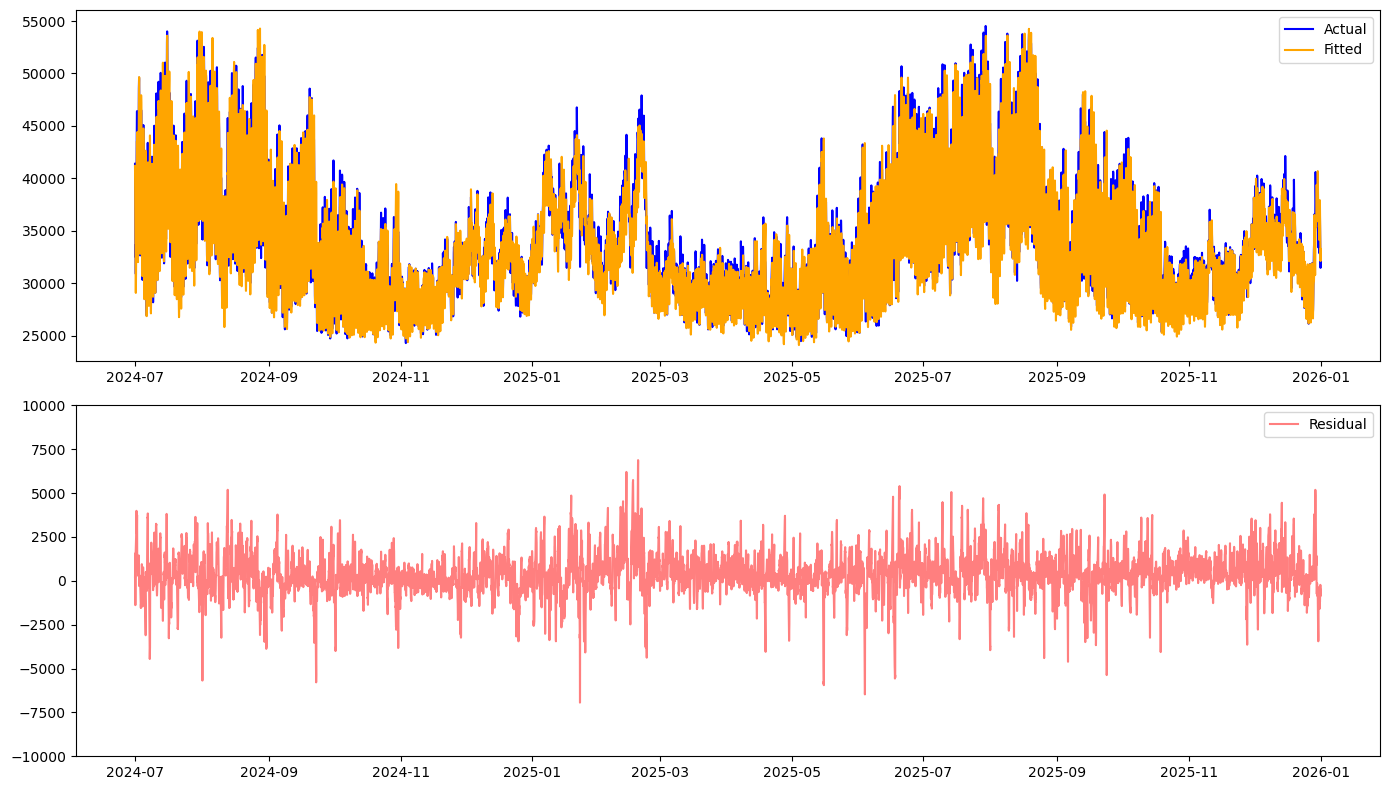

In [91]:
plot_pred_real_res(predictions)

In [ ]:
"""
#create residual series with the acutal date index
residuals = pd.Series(
            forecaster.in_sample_residuals_,
            index = data.loc[:VAL_END].index[-len(forecaster.in_sample_residuals_):]
)
residuals.head()
"""

In [ ]:
"""
outliers = residuals.abs().sort_values(ascending=False).head(10)
print(outliers)
"""

multiple dates have the exact same residual which is highly unlikely so there is probably an error in the data pipeline causing duplicates

In [ ]:
"""
#create the x train and y train data sets, including the lags to see if the rows are duplicated for a specific date
X_train, y_train = forecaster.create_train_X_y(
    y=data.loc[:VAL_END, 'Demand'],
    exog=data.loc[:VAL_END, exog_select]
)

dates_to_check = ["2024-11-19 08:00:00", "2024-05-26 07:00:00"]
print(X_train.loc[dates_to_check])
print(y_train.loc[dates_to_check])
"""

In [ ]:
"""
#check the raw date data
print(df.loc[dates_to_check, "Demand"])
"""

In [43]:
"""
def plot_outlier_window(date, window_hours=48):
    start = date - pd.Timedelta(hours=window_hours)
    end = date + pd.Timedelta(hours=window_hours)

    window_data = data.loc[start:end]
    window_resid = residuals.loc[start:end]

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

    axes[0].plot(window_data.index, window_data["Demand"], label="Demand", color="blue", marker = "o")
    axes[0].axvline(date, color="red", linestyle="--", alpha=0.5)
    axes[0].set_ylabel("Demand")
    axes[0].legend()

    axes[1].plot(window_data.index, window_data["Temperature"], label="Temperature", color="orange", marker = "o")
    axes[1].axvline(date, color="red", linestyle="--", alpha=0.5)
    axes[1].set_ylabel("Temperature")
    axes[1].legend()

    axes[2].plot(window_resid.index, window_resid, label="Residual", color="green")
    axes[2].axhline(0, color="black", linestyle="--", alpha=0.3)
    axes[2].axvline(date, color="red", linestyle="--", alpha=0.5)
    axes[2].set_ylabel("Residual")
    axes[2].legend()

    plt.suptitle(f"Outlier Window — {date}")
    plt.tight_layout()
    plt.show()
"""

In [ ]:
#plot_outlier_window(outliers.index[0])

In [45]:
"""
def plot_outlier_exog_window(date, window_hours=48):
    start = date - pd.Timedelta(hours=window_hours)
    end = date + pd.Timedelta(hours=window_hours)

    window_data = data.loc[start:end]
    window_resid = residuals.loc[start:end]

    exog_cols = ['Holiday', 'week', 'day_of_week', 'hour',
                 'week_sin', 'week_cos', 'day_sin', 'hour_sin', 'hour_cos']

    fig, axes = plt.subplots(len(exog_cols) + 1, 1, figsize=(12, 2 * (len(exog_cols) + 1)), sharex=True)

    for i, col in enumerate(exog_cols):
        axes[i].plot(window_data.index, window_data[col], label=col, color="steelblue", marker = "o")
        axes[i].axvline(date, color="red", linestyle="--", alpha=0.5)
        axes[i].set_ylabel(col, fontsize=8)
        axes[i].legend(fontsize=7, loc="upper right")

    axes[-1].plot(window_resid.index, window_resid, label="Residual", color="green")
    axes[-1].axhline(0, color="black", linestyle="--", alpha=0.3)
    axes[-1].axvline(date, color="red", linestyle="--", alpha=0.5)
    axes[-1].set_ylabel("Residual", fontsize=8)
    axes[-1].legend(fontsize=7, loc="upper right")

    plt.suptitle(f"Exogenous Features Around Outlier — {date}")
    plt.tight_layout()
    plt.show()
"""


In [ ]:
"""
# Plot top outlier
plot_outlier_exog_window(outliers.index[0])
"""

In [ ]:
"""
# Get the exact features used for this prediction
X_train, y_train = forecaster.create_train_X_y(
    y=data.loc[:VAL_END, 'Demand'],
    exog=data.loc[:VAL_END, exog_select]
)

# Find the row corresponding to your outlier date
outlier_date = outliers.index[0]
print(X_train.loc[outlier_date])
"""

### Hyper Parameter Tuning

In [92]:
# Hyperparameters search
# ==============================================================================
"""
### Train Val Test Split
TRAIN_START = "2023-01-01 00:00:00"
TRAIN_END   = "2024-06-30 23:00:00"
VAL_START   = "2024-07-01 00:00:00"
VAL_END     = "2024-12-31 23:00:00"
TEST_START  = "2025-01-01 00:00:00"
TEST_END    = "2025-12-31 23:00:00"
"""
tuned_forecaster = ForecasterRecursive(
                 estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                 lags            = top_lags
             )

# Estimator hyperparameters search space
def search_space(trial):
    search_space  = {
        'n_estimators' : trial.suggest_int('n_estimators', 300, 1000, step=100),
        'max_depth'    : trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.5),
        'reg_alpha'    : trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda'   : trial.suggest_float('reg_lambda', 0, 1),
    } 
    return search_space

# Folds training and validation
cv_search = TimeSeriesFold(
                steps              = 24,
                initial_train_size = len(data[:TRAIN_END]),
                refit              = False,
            )

results_search, frozen_trial = bayesian_search_forecaster(
                                   forecaster   = tuned_forecaster,
                                   y            = data.loc[:VAL_END, 'Demand'],
                                   exog         = data.loc[:VAL_END, top_exog],
                                   cv           = cv_search,
                                   metric       = 'mean_absolute_error',
                                   search_space = search_space,
                                   n_trials     = 30,  # Increase for more exhaustive search
                                   return_best  = True
                               )
tuned_forecaster

/Users/maxwellgriffith/miniconda3/envs/loadcast/lib/python3.11/site-packages/optuna/samplers/_tpe/sampler.py:82: FutureWarning: `consider_endpoints` has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  optuna_warn(msg, FutureWarning)
Best trial: 28. Best value: 781.794: 100%|█████████████████████████| 30/30 [00:50<00:00,  1.69s/it]


=================== 
ForecasterRecursive 
=================== 
Estimator: LGBMRegressor 
Lags: [ 1  2  3  4 18 20 21 22 23 24 25 26 27 28 29] 
Window features: None 
Window size: 29 
Series name: Demand 
Exogenous included: True 
Exogenous names: 
    Temperature, Holiday, week, day_of_week, hour, week_cos, hour_sin, hour_cos,
    Temp_2D_Min, week_sin 
Categorical features: auto 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Drop NaN from series: False 
Training range: [Timestamp('2023-01-01 00:00:00'), Timestamp('2024-12-31 23:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Hour> 
Estimator parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.1729129310846998,
    'max_depth': 4, 'min_child_samples': 20, 'min_child_weight': 0.001,
    'min_split_gain': 0.0, 'n_estimators': 500, 'n_jobs': None, 'num_leaves':
    31, 'objective': None, 'random_state': 15926, 'reg_alpha':
    0.9499613888711852, 'reg_lambda': 0.834361021671198, 'subsample': 1.0,
    'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1} 
fit_kwargs: {} 
Creation date: 2026-07-06 10:38:04 
Last fit date: 2026-07-06 10:38:55 
Skforecast version: 0.22.0 
Python version: 3.11.13 
Forecaster id: None

In [93]:
# Backtest final model on test data
# ==============================================================================
metric, predictions = backtesting_forecaster(
                          forecaster = tuned_forecaster,
                          y          = data['Demand'],
                          exog       = data[top_exog],
                          cv         = cv,
                          metric     = 'mean_absolute_error'
                      )
metric

100%|███████████████████████████████████████████████████████████| 549/549 [00:02<00:00, 189.44it/s]


,mean_absolute_error
0,911.502448


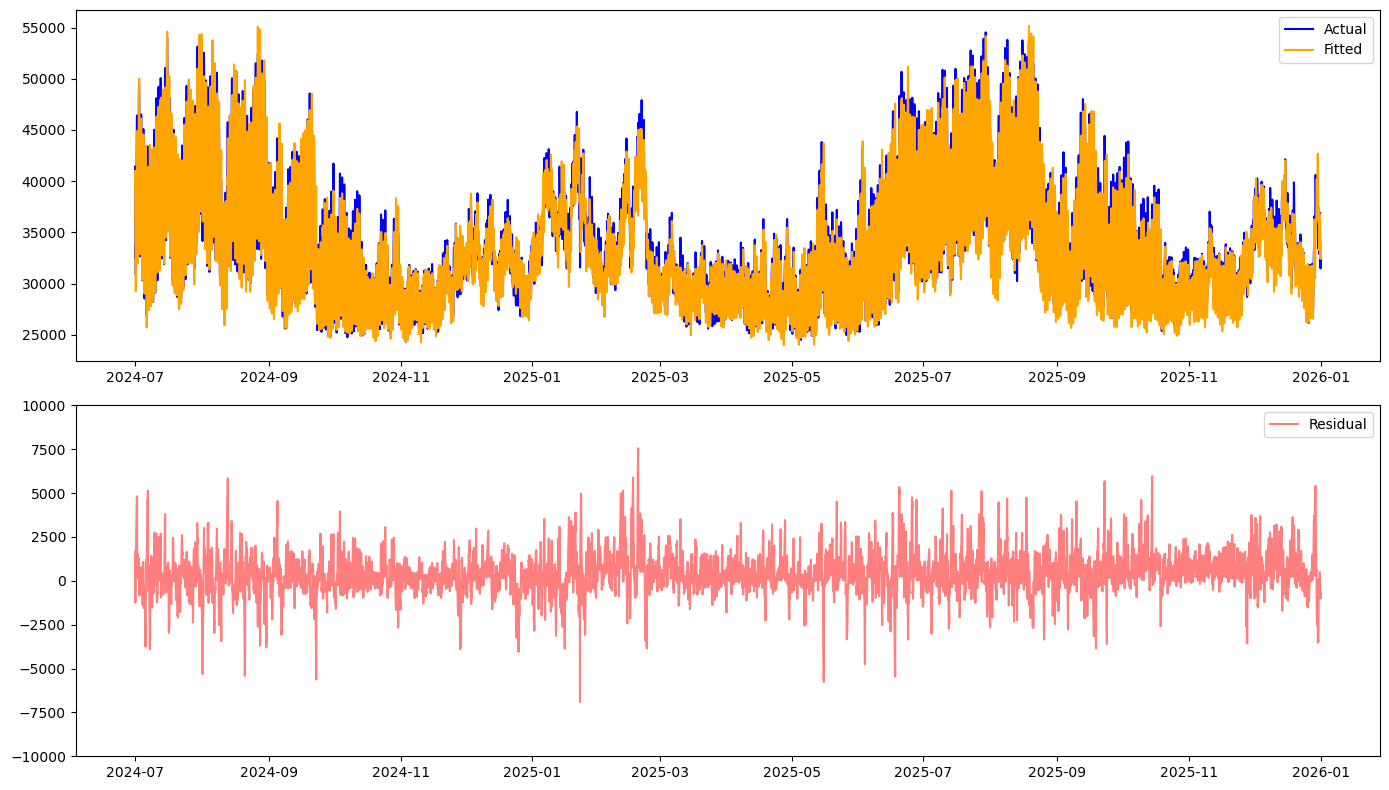

In [94]:
plot_pred_real_res(predictions)

-well the error went up so idk what to do about that

## Retrain model with "gap"
- to pull the most recent actual load data from gridstatus there is a 1 day delay
- if today is D then grid status publishes the actual load from day D-1 and but we want to predict D+1
- so we need to prediction 48 steps for D and D+1 (gap = 24, step =24)
- Training data must end where the gap begins.
- use "gap" and "allow_incomplete_fold" arguments

In [ ]:
# Backtesting with gap
# ==============================================================================
cv_gap = TimeSeriesFold(
        steps              = 24,
        initial_train_size = len(data.loc[:VAL_END]) + 24,
        refit              = False,
        gap                = 24,
)

metric, predictions = backtesting_forecaster(
                          forecaster = tuned_forecaster,
                          y          = data['Demand'],
                          exog       = data[top_exog],
                          cv         = cv_gap,
                          metric     = 'mean_absolute_error'
                      )
metric
predictions.head(5)